In [1]:
# Resolve project imports and data paths when this notebook runs in analysis/.
from pathlib import Path
import os
import sys

ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "run.py").is_file()
     and (folder / "GNN" / "GNN_utils.py").is_file()),
    None,
)
if ROOT is None:
    raise RuntimeError("Start this notebook from within the ligo-opt repository.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import numpy as np
import finesse
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from utils.finesse_base import base_kat
from finesse.knm import Map
from finesse.utilities.maps import circular_aperture
from oracles import finesse_sim
from GNN.GNN_run import GNNPowerPredictor
from tqdm import tqdm
import pickle
from finesse.analysis.actions.operator import Eigenmodes

/home/xuesi.ma/.conda/envs/ligoopt/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Check if the subspace created by ITM ROC and ETM ROC are different

In [2]:
ITM_ROC_nominal = -1934
ETM_ROC_nominal = 2245


ITM_ROC_List = np.linspace(ITM_ROC_nominal - 2200, ITM_ROC_nominal + 500, 50)
ETM_ROC_List = np.linspace(ETM_ROC_nominal - 500, ETM_ROC_nominal + 2000, 50)

# find_q_kat = base_kat.deepcopy()
# find_q_kat.parse(f"bp q_value ITM.p1.i prop=q")
# q_value = find_q_kat.run()["q_value"]
# print(q_value)

In [3]:
def _kat_simulation(base_kat, ITM_roc, ETM_roc):
    kat_sim = base_kat.deepcopy()
    # kat_sim.parse(f"gauss fixed_q_value ITM.p1.i q={q_value}")
    kat_sim.ITM.Rc = ITM_roc
    kat_sim.ETM.Rc = ETM_roc
    # Finesse requires each beam spot radius to span at least 10 map intervals.
    # For this ROC grid the smallest traced spot is about 16.7 mm, so 401
    # points (dx=0.85 mm, about 19.6 intervals/spot) provides a safe margin.
    x = y = np.linspace(-0.17, 0.17, 501)
    kat_sim.ITM.surface_map = Map(x, y, amplitude=circular_aperture(x,y,0.17))
    kat_sim.ETM.surface_map = Map(x, y, amplitude=circular_aperture(x,y,0.17))
    
    # Beam size (1/e^2 intensity radius) of the cavity mode at each mirror,
    # read straight from finesse's beam tracing via bp detectors (same mechanism
    # as the q_{node} detectors utils/finesse_base.py already adds for every
    # node). Use the intra-cavity nodes: ITM.p2.o is the beam leaving ITM into
    # the cavity (the cavArm source), ETM.p1.i the beam arriving at ETM. With
    # the thin (L=0) mirrors here all ports of a mirror give the same w.
    kat_sim.parse("bp w_ITM ITM.p2.o prop=w")
    kat_sim.parse("bp w_ETM ETM.p1.i prop=w")
    # NOTE: previously used `cp rt_loss cavArm prop=loss` which only returns the
    # intrinsic cavity loss (1 - prod(R) * prod(T) from mirror T/L params).
    # That value is a constant ~0.014 regardless of ROC or aperture; it ignores
    # diffraction loss from the circular_aperture surface maps entirely. The
    # total round-trip loss (including diffraction) is computed below via the
    # Eigenmodes action, which builds the full round-trip operator including
    # HOM/modal effects from surface maps.
    
    if not kat_sim.cavArm.is_stable:
        # print(f"cavArm is not stable for {ITM_roc} and {ETM_roc}")
        return 0, 0, 0, 0
    
    try:
        ref_power = kat_sim.run("""Series(
                        run_locks(max_iterations=100000,),
                        noxaxis(),
                        )""")
    except (finesse.exceptions.LostLock, Exception) as e:
        print(f"lock failed: {e}")
        return 0, 0, 0, 0
    
    result = ref_power["noxaxis"]
    
    # Total round-trip loss including diffraction from surface maps.
    # sol.loss() returns (sorted_indices, loss_array) ordered by ascending loss
    # so idx[0] is the lowest-loss (fundamental) mode.
    sol = kat_sim.run(Eigenmodes(kat_sim.cavArm, frequency=0.0))
    idx, total_loss = sol.loss(remove_planewave_loss=False)
    rt_loss = float(total_loss[idx[0]])
    
    return result["p_ETM_p1_i"], result["w_ITM"], result["w_ETM"], rt_loss


#### Finesse simulation of this subspace

In [22]:
power_list = {
    "ITM_ROC": [],
    "ETM_ROC": [],
    "Power": [],
    "w_ITM": [],
    "w_ETM": [],
    "Loss": []
}
total_data_points = len(ITM_ROC_List) * len(ETM_ROC_List)

with tqdm(total=total_data_points) as pbar:
    for ITM_roc in ITM_ROC_List:
        for ETM_roc in ETM_ROC_List:
            power, w_ITM, w_ETM, loss = _kat_simulation(base_kat, ITM_roc, ETM_roc)

            power_list["ITM_ROC"].append(ITM_roc)
            power_list["ETM_ROC"].append(ETM_roc)
            power_list["Power"].append(power)
            power_list["w_ITM"].append(w_ITM)
            power_list["w_ETM"].append(w_ETM)
            power_list["Loss"].append(loss)
            
            pbar.set_description(f"ITM_ROC={ITM_roc}, ETM_ROC={ETM_roc}")
            pbar.update(1)


ITM_ROC=-4134.0, ETM_ROC=1745.0:   0%|          | 0/2500 [00:00<?, ?it/s]

ITM_ROC=-1985.0204081632655, ETM_ROC=3938.877551020408:  80%|███████▉  | 1994/2500 [10:44<03:53,  2.17it/s] /home/xuesi.ma/.conda/envs/ligoopt/lib/python3.13/site-packages/finesse/analysis/actions/base.py:160: UserWarning: Spot size vs map resolution is low, increase map resolution or spot size
for ITM connection 1->1
  self.__sim.__enter__()
/home/xuesi.ma/.conda/envs/ligoopt/lib/python3.13/site-packages/finesse/analysis/actions/base.py:160: UserWarning: Spot size vs map resolution is low, increase map resolution or spot size
for ITM connection 2->2
  self.__sim.__enter__()
/home/xuesi.ma/.conda/envs/ligoopt/lib/python3.13/site-packages/finesse/analysis/actions/base.py:160: UserWarning: Spot size vs map resolution is low, increase map resolution or spot size
for ITM connection 1->2
  self.__sim.__enter__()
/home/xuesi.ma/.conda/envs/ligoopt/lib/python3.13/site-packages/finesse/analysis/actions/base.py:160: UserWarning: Spot size vs map resolution is low, increase map resolution or spo

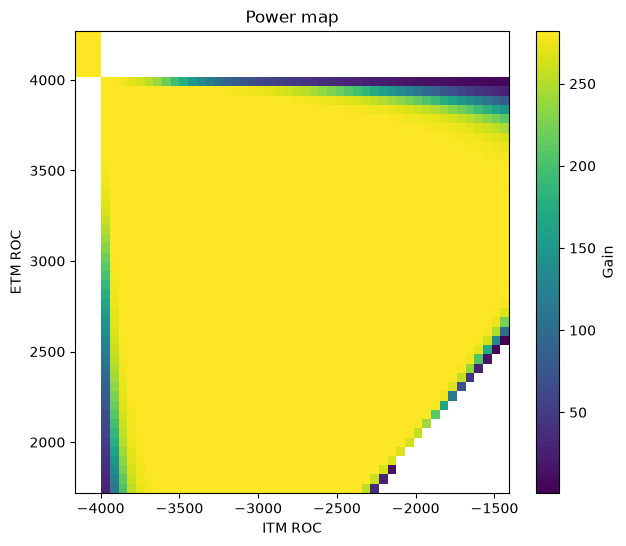

In [23]:
# Reshape the flattened power list into a 2D grid
power_values = np.array(power_list["Power"], dtype=float)
power_grid = power_values.reshape(len(ITM_ROC_List), len(ETM_ROC_List))
# A zero is the sentinel returned when the cavity cannot lock, not a real power.
# Replace it only in the plotting copy so the underlying simulation data is unchanged.
power_grid_plot = np.where(power_grid == 0, np.nan, power_grid)

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List, indexing='ij')

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, power_grid_plot, cmap='viridis', shading='auto')
plt.colorbar(label='Gain')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Power map')
x_point, y_point = -2434, 2228.76871493  # replace with your actual coordinates
# plt.plot(x_point, y_point, 'ro', markersize=8)
plt.savefig("Figures/power_map_finesse.png")
plt.show()

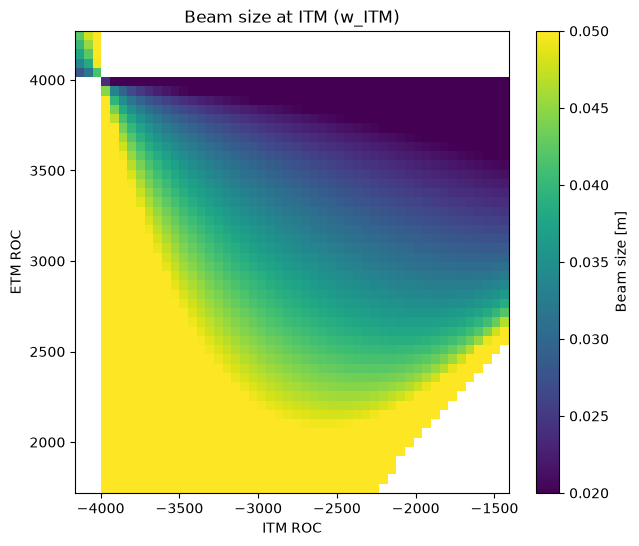

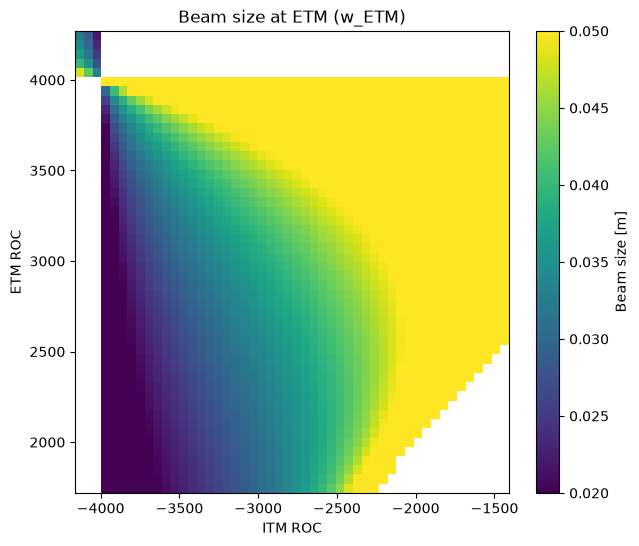

In [8]:
# Reshape the flattened beam-size lists into 2D grids (same as the power map)
w_ITM_values = np.array(power_list["w_ITM"], dtype=float)
w_ETM_values = np.array(power_list["w_ETM"], dtype=float)
w_ITM_grid = w_ITM_values.reshape(len(ITM_ROC_List), len(ETM_ROC_List))
w_ETM_grid = w_ETM_values.reshape(len(ITM_ROC_List), len(ETM_ROC_List))
# Zero indicates that the cavity could not lock, not a real beam size.
# Replace it only in plotting copies so the simulation data remains unchanged.
w_ITM_grid_plot = np.where(w_ITM_grid == 0, np.nan, w_ITM_grid)
w_ETM_grid_plot = np.where(w_ETM_grid == 0, np.nan, w_ETM_grid)

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List, indexing='ij')

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, w_ITM_grid_plot, cmap='viridis', shading='auto', vmin=0.02, vmax=0.05)
plt.colorbar(label='Beam size [m]')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Beam size at ITM (w_ITM)')
plt.savefig("Figures/w_ITM_map_finesse.png")
plt.show()

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, w_ETM_grid_plot, cmap='viridis', shading='auto', vmin=0.02, vmax=0.05)
plt.colorbar(label='Beam size [m]')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Beam size at ETM (w_ETM)')
plt.savefig("Figures/w_ETM_map_finesse.png")
plt.show()


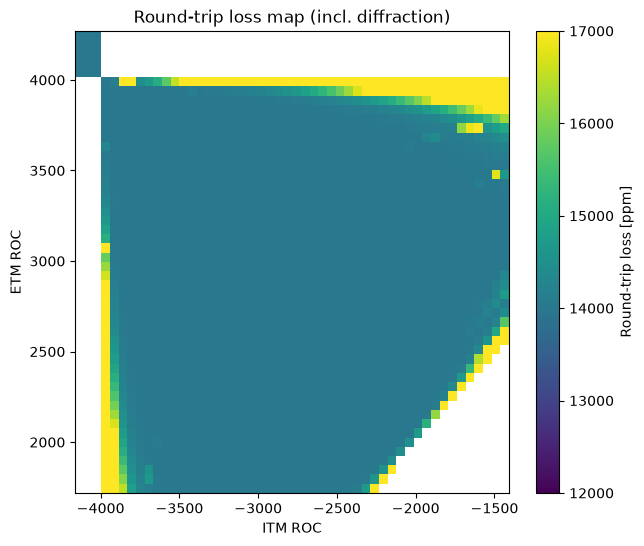

In [9]:
# Reshape the flattened round-trip-loss list into a 2D grid
# (same shape as the power and beam-size maps).
# NOTE: with the fixed _kat_simulation, these values now include
# diffraction loss from the circular_aperture surface maps and vary
# with ITM/ETM ROC, unlike the old cp prop=loss detector which was
# a constant ~0.014.
loss_values = np.array(power_list["Loss"], dtype=float)
loss_grid = loss_values.reshape(len(ITM_ROC_List), len(ETM_ROC_List))
# Zero indicates that the cavity could not lock, not a real round-trip loss.
# Replace it only in the plotting copy so the simulation data remains unchanged.
loss_grid_plot = np.where(loss_grid == 0, np.nan, loss_grid)

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List, indexing='ij')

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, loss_grid_plot * 1e6, cmap='viridis', shading='auto', vmin=12000, vmax=17000)
plt.colorbar(label='Round-trip loss [ppm]')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Round-trip loss map (incl. diffraction)')
plt.savefig("Figures/rt_loss_map_finesse.png")
plt.show()


In [9]:
ITM_arr = np.array(ITM_ROC_List)
ETM_arr = np.array(ETM_ROC_List)
i = np.argmin(np.abs(ITM_arr - -3434))
j = np.argmin(np.abs(ETM_arr - 3300))
print("currently best power from PSO: ",power_grid[i, j])
print("currently best power from grid search: ", np.max(power_grid))

currently best power from PSO:  282.09552140737105
currently best power from grid search:  282.0955214076213


#### GNN simulation of the subspace

In [19]:
kat_GNN = base_kat.deepcopy()
model_path = "GNN/models/run12/power_predictor_ligoParams_finetuned_round40.pt"
# model_path = "GNN/models/run11/base_30_gat10_kan5.pt"
pd_name = "p_ETM_p1_i"
power_list_GNN = []
total_data_points = len(ITM_ROC_List) * len(ETM_ROC_List)

predictor_GNN = GNNPowerPredictor(model_path)

with tqdm(total=total_data_points) as pbar:
    for ITM_roc in ITM_ROC_List:
        for ETM_roc in ETM_ROC_List:
            kat_GNN.ITM.Rc = ITM_roc
            kat_GNN.ETM.Rc = ETM_roc

            name, powers = predictor_GNN.run(kat_GNN)


            index = name.index(pd_name)
            ref_power = powers[index]

            power_list_GNN.append(ref_power)
            
            pbar.set_description(f"ITM_ROC={ITM_roc}, ETM_ROC={ETM_roc}")
            pbar.update(1)


ITM_ROC=-1434.0, ETM_ROC=4245.0: 100%|██████████| 2500/2500 [00:43<00:00, 57.86it/s]                        


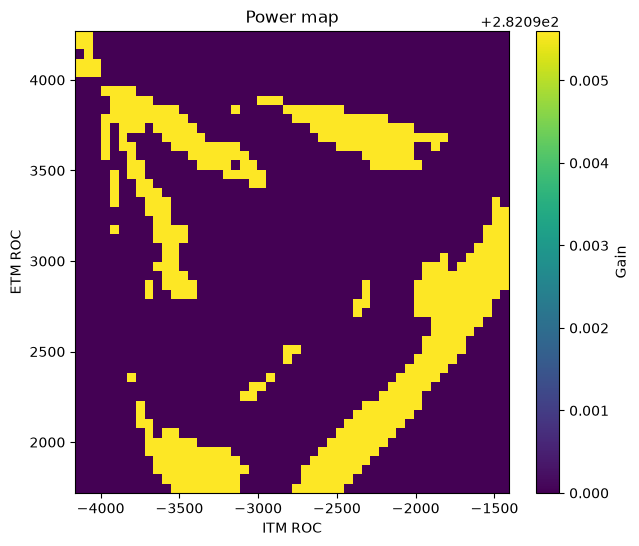

In [21]:
# Reshape the flattened power list into a 2D grid
power_grid_GNN = np.array(power_list_GNN).reshape(len(ITM_ROC_List), len(ETM_ROC_List))
# Zero indicates an invalid prediction, not a real power value.
# Replace it only in the plotting copy so the GNN data remains unchanged.
power_grid_GNN_plot = np.where(power_grid_GNN <= 0, np.nan, power_grid_GNN)

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List, indexing='ij')

plt.figure(figsize=(7, 6))
plt.pcolormesh(X, Y, power_grid_GNN, cmap='viridis', shading='auto', vmin=282.09, vmax=282.0956) 
plt.colorbar(label='Gain')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Power map')
x_point, y_point = -2434, 2228.76871493 
# plt.plot(x_point, y_point, 'ro', markersize=8)
plt.savefig('Figures/power_map_GNN_full_zoomed.png')
plt.show()

In [15]:
print(power_grid_GNN)

[[2.85558542e-03 3.27583100e-03 3.31811025e-03 ... 2.74753876e+02
  2.73871826e+02 2.71047607e+02]
 [7.81417266e-03 8.08819104e-03 8.63037910e-03 ... 2.73051636e+02
  2.49810532e+02 2.31975311e+02]
 [1.35471979e-02 1.36421099e-02 1.47168469e-02 ... 1.78722473e+02
  1.70646606e+02 1.55284821e+02]
 ...
 [1.52703667e+00 1.53823256e+00 1.55158377e+00 ... 2.74123597e+00
  2.78747416e+00 2.83527493e+00]
 [1.57435763e+00 1.58746958e+00 1.60154700e+00 ... 2.79266882e+00
  2.84002185e+00 2.89080191e+00]
 [1.62121403e+00 1.63484883e+00 1.64936769e+00 ... 2.85482144e+00
  2.90411353e+00 2.95742822e+00]]


#### Read the result

In [24]:
run_num = 12
with open(f"GNN/data/run{run_num}/final_result.pkl", "rb") as f:
    final_result = pickle.load(f)

In [5]:
# Calculate nominal powers once; plot in the next cell.
from pathlib import Path

# Match run.py: round 1 uses the base model; round N uses checkpoint N-1.
comparison_model_dir = Path(f"GNN/models/run{run_num}")
# Base checkpoint names can differ between runs.
comparison_base_checkpoints = sorted(comparison_model_dir.glob("base_*.pt"))
if len(comparison_base_checkpoints) != 1:
    raise ValueError(
        f"Expected exactly one base checkpoint in {comparison_model_dir}, "
        f"found {len(comparison_base_checkpoints)}: {comparison_base_checkpoints}"
    )
comparison_base_checkpoint = comparison_base_checkpoints[0]
nominal_pd_name = "p_ETM_p1_i"
nominal_points = np.asarray(final_result["data"], dtype=float)
if nominal_points.ndim != 2 or nominal_points.shape[1] != 2:
    raise ValueError("Expected final_result['data'] to contain [ITM ROC, ETM ROC] pairs.")

comparison_checkpoint_paths = [
    comparison_model_dir / (
        comparison_base_checkpoint.name if iteration == 0
        else f"power_predictor_ligoParams_finetuned_round{iteration}.pt"
    )
    for iteration in range(len(nominal_points))
]
missing_checkpoints = [str(path) for path in comparison_checkpoint_paths if not path.is_file()]
if missing_checkpoints:
    raise FileNotFoundError(f"Missing round-specific checkpoints: {missing_checkpoints}")

nominal_power_gnn = np.full(len(nominal_points), np.nan)
nominal_power_finesse = np.full(len(nominal_points), np.nan)
for iteration, (itm_roc, etm_roc) in enumerate(tqdm(nominal_points, desc="Nominal power")):
    nominal_predictor = GNNPowerPredictor(str(comparison_checkpoint_paths[iteration]))
    nominal_kat = base_kat.deepcopy()
    nominal_kat.ITM.Rc = itm_roc
    nominal_kat.ETM.Rc = etm_roc
    names, powers = nominal_predictor.run(nominal_kat)
    nominal_power_gnn[iteration] = float(powers[names.index(nominal_pd_name)])
    power, _, _, _ = _kat_simulation(base_kat, itm_roc, etm_roc)
    nominal_power_finesse[iteration] = float(power)


Nominal power: 100%|██████████| 40/40 [00:53<00:00,  1.33s/it]


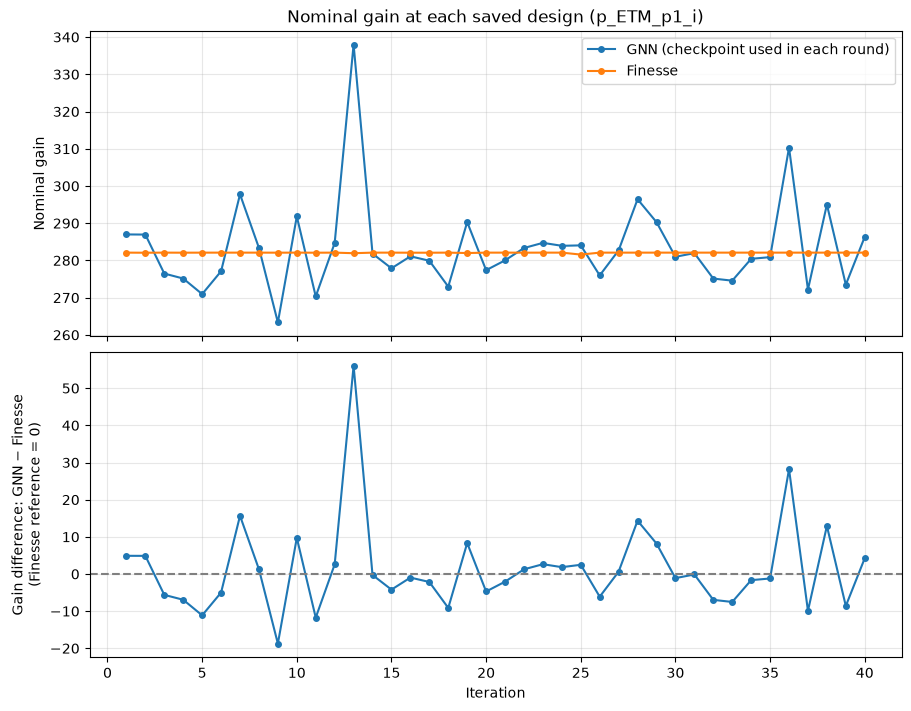

In [17]:
# Replot cached calculation results without running GNN or Finesse.
from pathlib import Path

comparison_figure_dir = Path("Figures")
comparison_figure_dir.mkdir(parents=True, exist_ok=True)

# Non-positive powers indicate failed/invalid evaluations; plot them as gaps.
nominal_power_gnn_plot = np.where(
    np.isfinite(nominal_power_gnn) & (nominal_power_gnn > 0), nominal_power_gnn, np.nan
)
nominal_power_finesse_plot = np.where(
    np.isfinite(nominal_power_finesse) & (nominal_power_finesse > 0), nominal_power_finesse, np.nan
)
nominal_power_difference = nominal_power_gnn_plot - nominal_power_finesse_plot
nominal_iterations = np.arange(1, len(nominal_points) + 1)

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)
axes[0].plot(nominal_iterations, nominal_power_gnn_plot, "o-", label="GNN (checkpoint used in each round)", markersize=4)
axes[0].plot(nominal_iterations, nominal_power_finesse_plot, "o-", label="Finesse", markersize=4)
axes[0].set_ylabel("Nominal gain")
axes[0].set_title(f"Nominal gain at each saved design ({nominal_pd_name})")
axes[0].legend()
axes[1].plot(nominal_iterations, nominal_power_difference, "o-", markersize=4)
axes[1].axhline(0, color="grey", linestyle="--")
axes[1].set_ylabel("Gain difference: GNN − Finesse\n(Finesse reference = 0)")
axes[1].set_xlabel("Iteration")
# axes[0].set_ylim(-0.1111+282.0955200,0.1111+282.0955200)
for ax in axes:
    ax.grid(alpha=0.3)
fig.savefig(
    comparison_figure_dir / f"run{run_num}_nominal_gain_gnn_vs_finesse_by_round.png",
    dpi=200, bbox_inches="tight",
)
plt.show()


In [8]:
# Calculate four fixed-q perturbations using the nominal calculation settings above.
# Four fixed-q perturbations, using the same simulation helpers as run.py.
# Avoid importing PSOoptimizer: sko changes multiprocessing state on import.
from GNN.GNN_utils import kat_manipulation
from oracles import finesse_sim
from perturbation import calc_perturbed_params
from utils.finesse_base import gnn_base_kat


def _comparison_power_output(itm_roc, etm_roc, nominal_q, template, predictor=None):
    kat = kat_manipulation(
        itm_roc, etm_roc, template, nominal_q_value=nominal_q,
        include_aperture_maps=predictor is None,
    )
    if predictor is None:
        names, powers, q_names, q_values = finesse_sim(kat)
    else:
        names, powers = predictor.run(kat)
        q_names, q_values = predictor._beam_q_values(kat)
    return names, powers, q_values[q_names.index("q_ITM_p1_i")]

perturbation_labels = {
    "ITM_plus": "ITM + ΔROC",
    "ITM_minus": "ITM − ΔROC",
    "ETM_plus": "ETM + ΔROC",
    "ETM_minus": "ETM − ΔROC",
}
perturbed_power_gnn = {key: np.full(len(nominal_points), np.nan) for key in perturbation_labels}
perturbed_power_finesse = {key: np.full(len(nominal_points), np.nan) for key in perturbation_labels}

for iteration, (itm_roc, etm_roc) in enumerate(tqdm(nominal_points, desc="Perturbed powers")):
    nominal_predictor = GNNPowerPredictor(str(comparison_checkpoint_paths[iteration]))
    (itm_plus, itm_minus), (etm_plus, etm_minus), _ = calc_perturbed_params(itm_roc, etm_roc)
    perturbed_points = {
        "ITM_plus": (itm_plus, etm_roc),
        "ITM_minus": (itm_minus, etm_roc),
        "ETM_plus": (itm_roc, etm_plus),
        "ETM_minus": (itm_roc, etm_minus),
    }
    for template, predictor, destination in (
        (gnn_base_kat, nominal_predictor, perturbed_power_gnn),
        (base_kat, None, perturbed_power_finesse),
    ):
        # Obtain each backend's nominal q exactly as in the optimization workflow.
        # No finetune_data_path: these comparisons do not append training data.
        _, _, nominal_q = _comparison_power_output(
            itm_roc, etm_roc, None, template,
            predictor=predictor,
        )
        for key, (perturbed_itm, perturbed_etm) in perturbed_points.items():
            names, powers, _ = _comparison_power_output(
                perturbed_itm, perturbed_etm, nominal_q, template,
                predictor=predictor,
            )
            destination[key][iteration] = float(powers[names.index(nominal_pd_name)])



Perturbed powers: 100%|██████████| 40/40 [01:54<00:00,  2.86s/it]


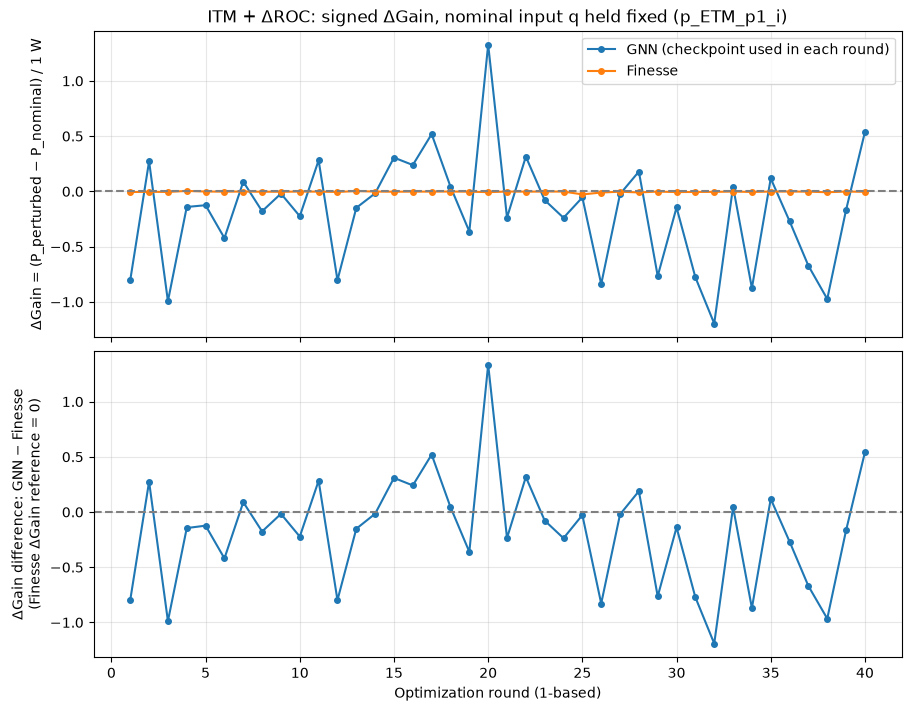

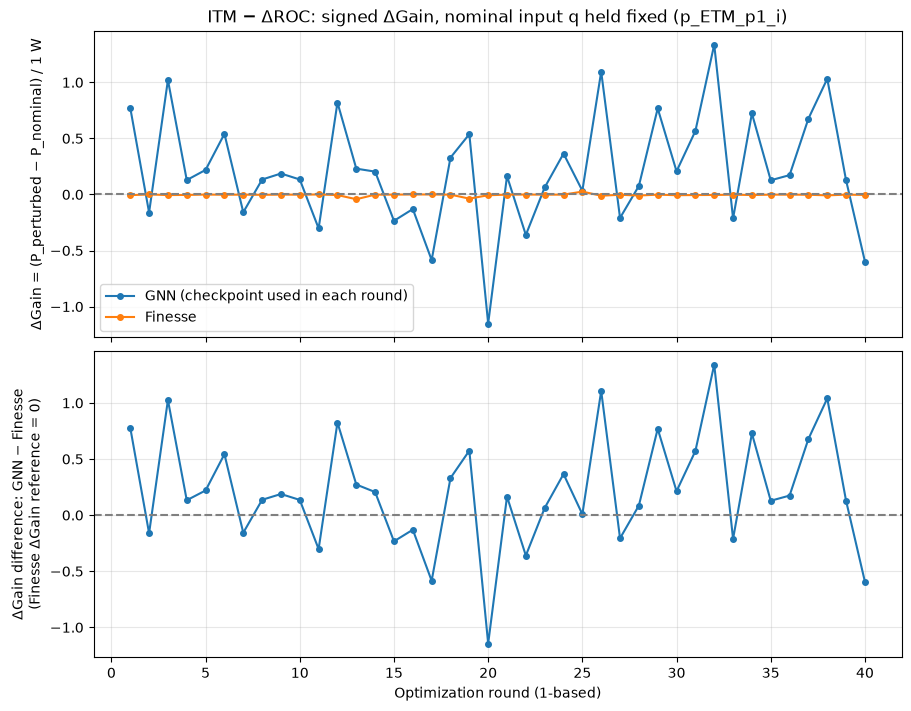

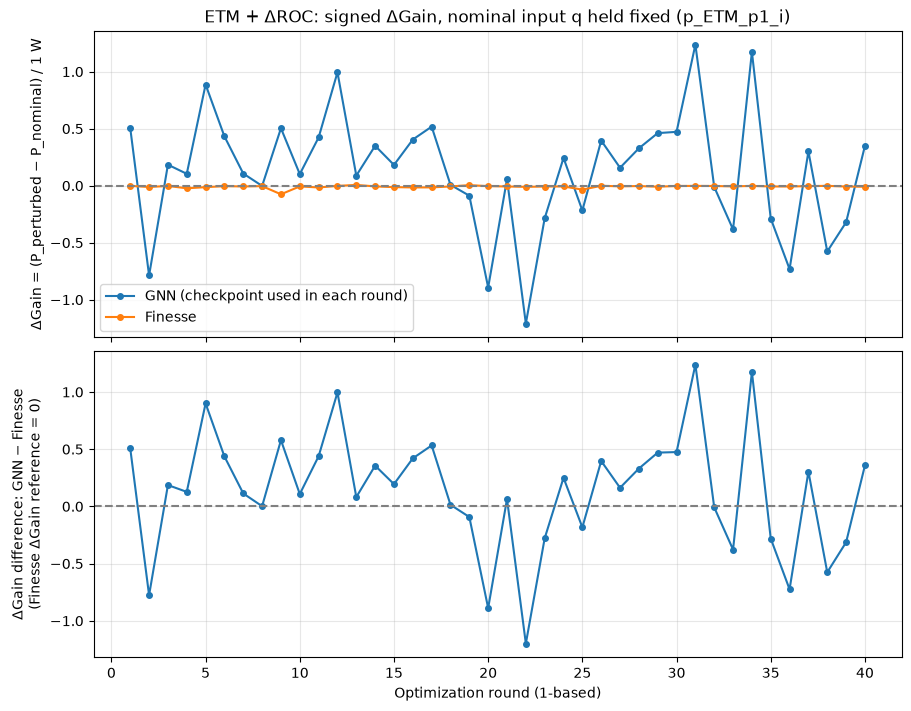

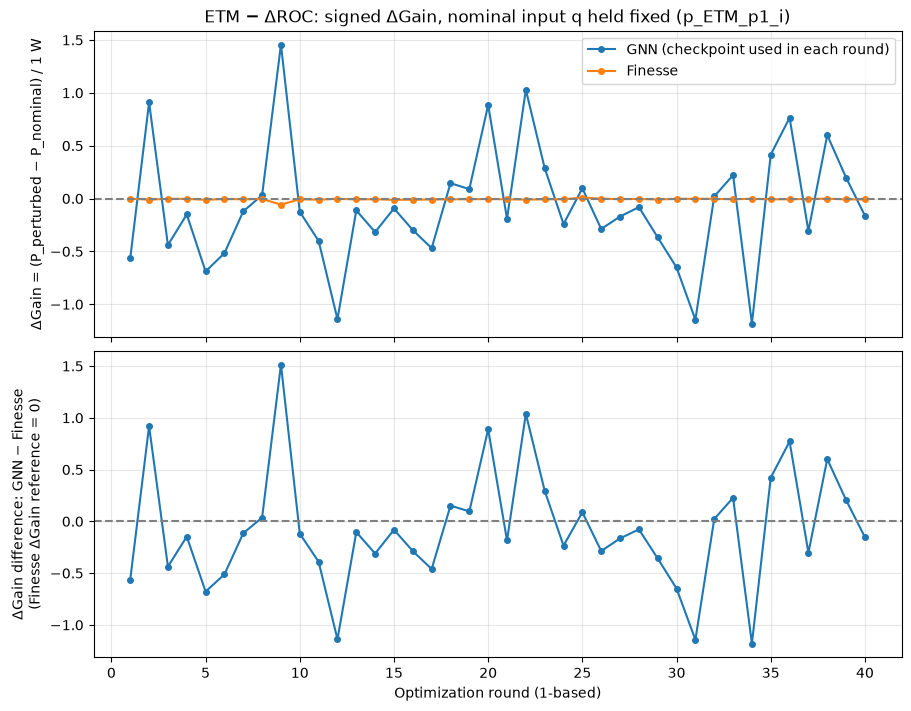

In [9]:
# Plot cached perturbation deltas; requires the nominal and perturbation calculation cells.
from pathlib import Path

comparison_figure_dir = Path("Figures")
comparison_figure_dir.mkdir(parents=True, exist_ok=True)
nominal_iterations = np.arange(1, len(nominal_points) + 1)

# Signed delta P from calc_gain_cost, before abs(), division by delta ROC,
# or summing directions. With 1 W input these values also equal delta gain.
delta_gain_gnn = {}
delta_gain_finesse = {}
delta_gain_difference = {}
for key, label in perturbation_labels.items():
    gnn_values = perturbed_power_gnn[key]
    finesse_values = perturbed_power_finesse[key]
    # The cost accepts zero perturbed power (complete power loss), but requires
    # positive nominal power. Keep invalid inputs as gaps, not zero delta gain.
    gnn_valid = (
        np.isfinite(gnn_values) & (gnn_values >= 0)
        & np.isfinite(nominal_power_gnn) & (nominal_power_gnn > 0)
    )
    finesse_valid = (
        np.isfinite(finesse_values) & (finesse_values >= 0)
        & np.isfinite(nominal_power_finesse) & (nominal_power_finesse > 0)
    )
    delta_gain_gnn[key] = np.where(gnn_valid, gnn_values - nominal_power_gnn, np.nan)
    delta_gain_finesse[key] = np.where(
        finesse_valid, finesse_values - nominal_power_finesse, np.nan
    )
    delta_gain_difference[key] = delta_gain_gnn[key] - delta_gain_finesse[key]

    fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)
    axes[0].plot(nominal_iterations, delta_gain_gnn[key], "o-", label="GNN (checkpoint used in each round)", markersize=4)
    axes[0].plot(nominal_iterations, delta_gain_finesse[key], "o-", label="Finesse", markersize=4)
    axes[0].axhline(0, color="grey", linestyle="--")
    axes[0].set_ylabel("ΔGain = (P_perturbed − P_nominal) / 1 W")
    axes[0].set_title(f"{label}: signed ΔGain, nominal input q held fixed ({nominal_pd_name})")
    axes[0].legend()
    axes[1].plot(nominal_iterations, delta_gain_difference[key], "o-", markersize=4)
    axes[1].axhline(0, color="grey", linestyle="--")
    axes[1].set_ylabel("ΔGain difference: GNN − Finesse\n(Finesse ΔGain reference = 0)")
    axes[1].set_xlabel("Optimization round (1-based)")
    for ax in axes:
        ax.grid(alpha=0.3)
    fig.savefig(
        comparison_figure_dir / f"run{run_num}_{key.lower()}_delta_gain_gnn_vs_finesse_by_round.png",
        dpi=200, bbox_inches="tight",
    )
    plt.show()


[0.0026325677214252678, 0.00320463935338584, 0.002555542641315466, 0.0036777213082315897, 0.0030470377942974636, 0.002493898298506942, 0.0026397990427191767, 0.0025066517547689244, 0.007363755221947427, 0.002614805403166672, 0.003132453278314666, 0.0025443472424801486, 0.004986269222582319, 0.0026094652225827847, 0.0032944902395091935, 0.003121284953744208, 0.003046228006391438, 0.0026547753226179227, 0.0044075054625949675, 0.003187818227353518, 0.0026806608571677652, 0.003036392628371498, 0.002690004978422261, 0.0026331553596565735, 0.009074468038735224, 0.002937735025410439, 0.002594291346211333, 0.0033988376715000895, 0.0028057398875271687, 0.0026739627908321747, 0.0025378860690144552, 0.0025216439822623622, 0.0026222513473962857, 0.0025362528077109356, 0.002646920118707108, 0.0026556399649088503, 0.0024879293665016674, 0.0027683873023679802, 0.002681643854771241, 0.002970369945748507]
[-3067.47506919  3374.80278975]


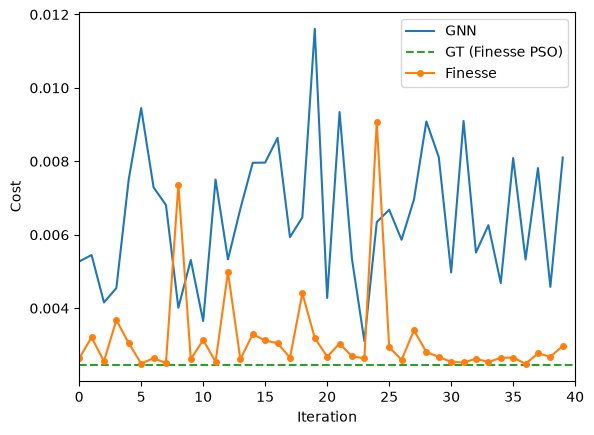

In [14]:
plt.plot(final_result["costs_gnn"], label="GNN")
# Keep non-finite costs as gaps and show isolated finite costs with markers.
GT_cost = 0.002461738070567913
plt.axhline(GT_cost, color="tab:green", linestyle="--", label="GT (Finesse PSO)")
costs_finesse = np.asarray(final_result["costs_finesse"], dtype=float)
costs_finesse_plot = np.where(np.isfinite(costs_finesse), costs_finesse, np.nan)
plt.plot(costs_finesse_plot, label="Finesse", marker="o", markersize=4)
print(final_result["costs_finesse"])
print(final_result["data"][-1])
plt.xlabel("Iteration")
plt.xlim(0, 40)
# plt.ylim(0.0035, 0.00365)
plt.ylabel("Cost")
plt.legend()
plt.savefig(f"Figures/run{run_num}_costs_full.png")

#### Add all the data points

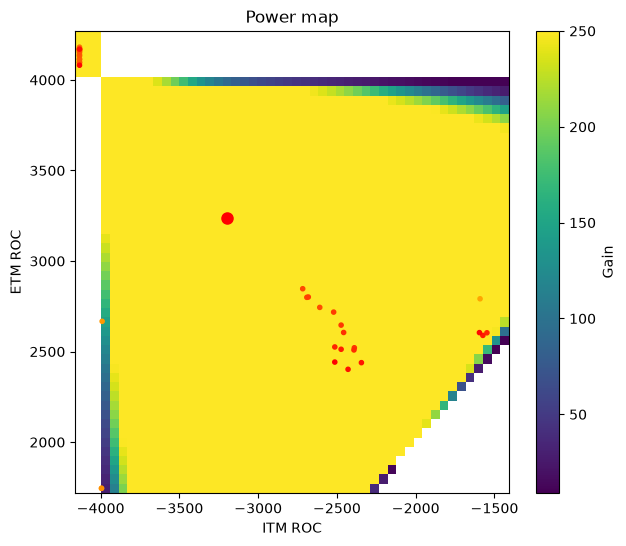

In [22]:
# Reshape the flattened power list into a 2D grid
power_values = np.array(power_list["Power"], dtype=float)
power_grid = power_values.reshape(len(ITM_ROC_List), len(ETM_ROC_List))

# Create the mesh for plotting
X, Y = np.meshgrid(ITM_ROC_List, ETM_ROC_List, indexing='ij')

plt.figure(figsize=(7, 6))
power_grid_plot = np.where(power_grid == 0, np.nan, power_grid)
plt.pcolormesh(X, Y, power_grid_plot, cmap='viridis', shading='auto', vmin=9, vmax=250)
plt.colorbar(label='Gain')
plt.xlabel('ITM ROC')
plt.ylabel('ETM ROC')
plt.title('Power map')
x_point, y_point = -3197.190261550587, 3237.233835349826  # replace with your actual coordinates
plt.plot(x_point, y_point, 'ro', markersize=8)

# All PSO-found optimum points across loop iterations (each [ITM_Roc, ETM_Roc]),
# colored orange -> red by index (redder = later/higher index).
data_arr = np.array(final_result["data"])
orange_red_cmap = LinearSegmentedColormap.from_list("orange_red", ["orange", "red"])
plt.scatter(data_arr[:, 0], data_arr[:, 1], c=np.arange(len(data_arr)), cmap=orange_red_cmap, s=9)

plt.savefig("Figures/power_map_finesse.png")
plt.show()

In [29]:
power_mpbax, _, _, _ = _kat_simulation(base_kat, final_result["data"][10][0], final_result["data"][10][1])
power_PSO, _, _, _ = _kat_simulation(base_kat, x_point, y_point)
print(power_mpbax, power_PSO)

282.095521407612 282.0955214075407


#### Cost Map for Perturbed

In [15]:
ITM_ROC_nominal = -1934
ETM_ROC_nominal = 2245


ITM_ROC_List = np.linspace(ITM_ROC_nominal - 2200, ITM_ROC_nominal + 500, 50)
ETM_ROC_List = np.linspace(ETM_ROC_nominal - 500, ETM_ROC_nominal + 2000, 50)

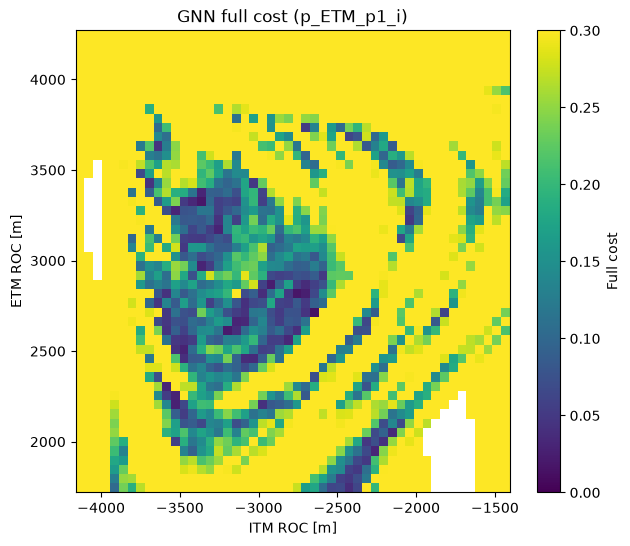

Minimum finite full cost: 0.012935903268086447
ITM ROC, ETM ROC: -2646.2448979591836 2714.387755102041
Loaded: GNN/data/subspace/full_cost_map_gnn_50x50_final.npz
Saved figure: Figures/full_cost_map_gnn_50x50_final.png
GNN checkpoint: /home/xuesi.ma/ligo-opt/GNN/models/run11/power_predictor_ligoParams_finetuned_round40.pt
Cost settings: {'cost_mode': 'full', 'full_perturbation_weight': 0.5, 'full_power_weight': 0.5, 'roc_perturbation_percent': 0.0033}


In [16]:
# Run this from the repository root first:
# /home/xuesi.ma/.conda/envs/ligoopt/bin/python perturbation_cost_map_gnn.py
# This cell only loads and plots the completed GNN result for COST_MODE.
from pathlib import Path
import json
import importlib
from utils import calc as gnn_calc
import numpy as np
import matplotlib.pyplot as plt

# Reload the saved settings when rerunning this cell after editing calc.py.
GNN_COST_MODE = importlib.reload(gnn_calc).COST_MODE
GNN_50X50_RESULT = Path(
    f"GNN/data/subspace/{GNN_COST_MODE}_cost_map_gnn_50x50_final.npz"
)
GNN_50X50_FIGURE = Path(
    f"Figures/{GNN_COST_MODE}_cost_map_gnn_50x50_final.png"
)

if not GNN_50X50_RESULT.is_file():
    raise FileNotFoundError(
        f"Standalone result not found: {GNN_50X50_RESULT.resolve()}"
    )

with np.load(GNN_50X50_RESULT) as saved:
    gnn_ITM_50 = saved["ITM_ROC_List"].copy()
    gnn_ETM_50 = saved["ETM_ROC_List"].copy()
    gnn_cost_50 = saved["cost_grid"].copy()
    gnn_complete_50 = saved["completed_grid"].astype(bool, copy=True)
    gnn_pd_name_50 = str(saved["pd_name"])
    gnn_cost_settings = json.loads(str(saved["cost_settings"]))
    gnn_model_path = str(saved["gnn_checkpoint_path"])

if gnn_cost_settings.get("cost_mode") != GNN_COST_MODE:
    raise ValueError("Saved map does not match COST_MODE; regenerate with perturbation_cost_map_gnn.py.")

if gnn_cost_50.shape != (50, 50):
    raise ValueError(f"Expected a 50x50 cost grid, got {gnn_cost_50.shape}.")
if gnn_complete_50.shape != (50, 50):
    raise ValueError(
        f"Expected a 50x50 completion grid, got {gnn_complete_50.shape}."
    )
if not gnn_complete_50.all():
    gnn_incomplete = gnn_complete_50.size - int(gnn_complete_50.sum())
    raise RuntimeError(
        f"Standalone calculation is incomplete ({gnn_incomplete} points remain). "
        "Rerun perturbation_cost_map_gnn.py to resume it."
    )

finite_gnn_cost_50 = gnn_cost_50[np.isfinite(gnn_cost_50)]
if finite_gnn_cost_50.size == 0:
    raise RuntimeError("The 50x50 result contains no finite costs.")

X_gnn_50, Y_gnn_50 = np.meshgrid(
    gnn_ITM_50, gnn_ETM_50, indexing="ij"
)
masked_gnn_cost_50 = np.ma.masked_where(
    ~np.isfinite(gnn_cost_50), gnn_cost_50
)
gnn_color_min_50, gnn_color_max_50 = np.percentile(finite_gnn_cost_50, [2, 98])
if gnn_color_min_50 == gnn_color_max_50:
    gnn_color_min_50, gnn_color_max_50 = None, None

plt.figure(figsize=(7, 6))
plt.pcolormesh(
    X_gnn_50,
    Y_gnn_50,
    masked_gnn_cost_50,
    shading="auto",
    cmap="viridis",
    vmin=0,
    vmax=0.3,
)
plt.colorbar(label=f"{GNN_COST_MODE.replace('_', ' ').capitalize()} cost")
plt.xlabel("ITM ROC [m]")
plt.ylabel("ETM ROC [m]")
plt.title(f"GNN {GNN_COST_MODE} cost ({gnn_pd_name_50})")
GNN_50X50_FIGURE.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(GNN_50X50_FIGURE, dpi=200, bbox_inches="tight")
plt.show()

gnn_finite_for_min = np.where(
    np.isfinite(gnn_cost_50), gnn_cost_50, np.nan
)
gnn_best_flat_50 = np.nanargmin(gnn_finite_for_min)
gnn_best_i_50, gnn_best_j_50 = np.unravel_index(gnn_best_flat_50, gnn_cost_50.shape)
print(f"Minimum finite {GNN_COST_MODE} cost:", gnn_cost_50[gnn_best_i_50, gnn_best_j_50])
print("ITM ROC, ETM ROC:", gnn_ITM_50[gnn_best_i_50], gnn_ETM_50[gnn_best_j_50])
print("Loaded:", GNN_50X50_RESULT)
print("Saved figure:", GNN_50X50_FIGURE)
print("GNN checkpoint:", gnn_model_path)
print("Cost settings:", gnn_cost_settings)


#### Load and plot standalone 50×50 perturbation map

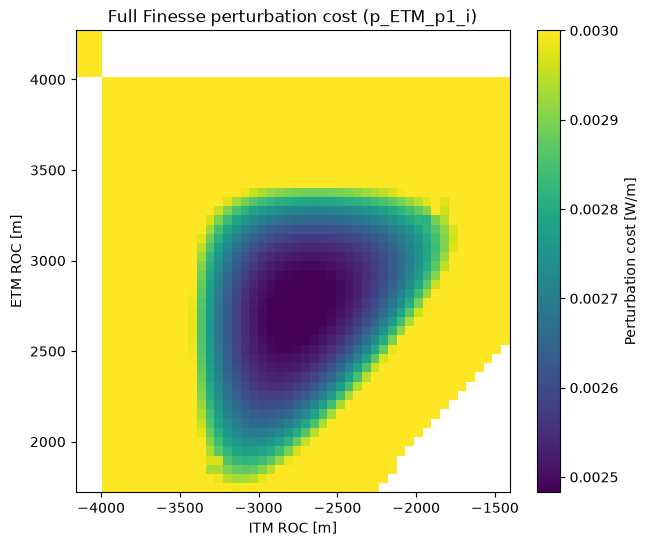

Minimum finite perturbation cost: 0.002462137051803532
ITM ROC, ETM ROC: -2756.448979591837 2714.387755102041
Loaded: GNN/data/subspace/full_cost_map_finesse_50x50.npz
Saved figure: Figures/perturbation_cost_map_finesse_zoom_50x50.png


In [18]:
# Run `python perturbation_cost_map_finesse.py` first. This cell only loads
# and plots its completed 50 x 50 result; it does not run Finesse.
from pathlib import Path

PERTURB_50X50_RESULT = Path(
    "GNN/data/subspace/full_cost_map_finesse_50x50.npz"
)
PERTURB_50X50_FIGURE = Path(
    "Figures/perturbation_cost_map_finesse_zoom_50x50.png"
)

if not PERTURB_50X50_RESULT.is_file():
    raise FileNotFoundError(
        f"Standalone result not found: {PERTURB_50X50_RESULT.resolve()}"
    )

with np.load(PERTURB_50X50_RESULT) as saved:
    perturb_ITM_50 = saved["ITM_ROC_List"].copy()
    perturb_ETM_50 = saved["ETM_ROC_List"].copy()
    perturb_cost_50 = saved["cost_grid"].copy()
    perturb_complete_50 = saved["completed_grid"].astype(bool, copy=True)
    perturb_pd_name_50 = str(saved["pd_name"])

if perturb_cost_50.shape != (50, 50):
    raise ValueError(f"Expected a 50x50 cost grid, got {perturb_cost_50.shape}.")
if perturb_complete_50.shape != (50, 50):
    raise ValueError(
        f"Expected a 50x50 completion grid, got {perturb_complete_50.shape}."
    )
if not perturb_complete_50.all():
    incomplete = perturb_complete_50.size - int(perturb_complete_50.sum())
    raise RuntimeError(
        f"Standalone calculation is incomplete ({incomplete} points remain). "
        "Rerun perturbation_cost_map_finesse.py to resume it."
    )

finite_perturb_cost_50 = perturb_cost_50[np.isfinite(perturb_cost_50)]
if finite_perturb_cost_50.size == 0:
    raise RuntimeError("The 50x50 result contains no finite perturbation costs.")

X_perturb_50, Y_perturb_50 = np.meshgrid(
    perturb_ITM_50, perturb_ETM_50, indexing="ij"
)
masked_perturb_cost_50 = np.ma.masked_where(
    ~np.isfinite(perturb_cost_50), perturb_cost_50
)
color_min_50, color_max_50 = np.percentile(finite_perturb_cost_50, [2, 98])
if color_min_50 == color_max_50:
    color_min_50, color_max_50 = None, None

plt.figure(figsize=(7, 6))
plt.pcolormesh(
    X_perturb_50,
    Y_perturb_50,
    masked_perturb_cost_50,
    shading="auto",
    cmap="viridis",
    vmin=color_min_50,
    vmax=0.003,
)
plt.colorbar(label="Perturbation cost [W/m]")
plt.xlabel("ITM ROC [m]")
plt.ylabel("ETM ROC [m]")
plt.title(f"Full Finesse perturbation cost ({perturb_pd_name_50})")
PERTURB_50X50_FIGURE.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(PERTURB_50X50_FIGURE, dpi=200, bbox_inches="tight")
plt.show()

finite_for_min = np.where(
    np.isfinite(perturb_cost_50), perturb_cost_50, np.nan
)
best_flat_50 = np.nanargmin(finite_for_min)
best_i_50, best_j_50 = np.unravel_index(best_flat_50, perturb_cost_50.shape)
print("Minimum finite perturbation cost:", perturb_cost_50[best_i_50, best_j_50])
print("ITM ROC, ETM ROC:", perturb_ITM_50[best_i_50], perturb_ETM_50[best_j_50])
print("Loaded:", PERTURB_50X50_RESULT)
print("Saved figure:", PERTURB_50X50_FIGURE)

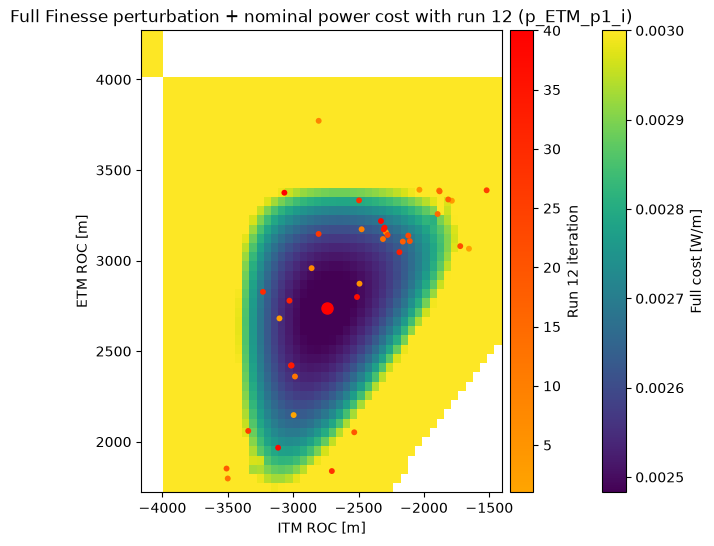

Run 12 points plotted: 40
Saved figure: Figures/full_cost_map_finesse_50x50_run12.png


In [25]:
# Plot the perturbation-cost map with every optimization point from the selected run.
# Point color progresses from orange to red as the iteration increases.
x_perturb_point, y_perturb_point = -2740.549129772132, 2740.458709488254

run_data = np.asarray(final_result["data"], dtype=float)
if run_data.ndim != 2 or run_data.shape[1] < 2:
    raise ValueError(
        f'Expected final_result["data"] to have shape (iterations, >=2), '
        f"got {run_data.shape}."
    )

run_iterations = np.arange(1, len(run_data) + 1)
orange_red_cmap = LinearSegmentedColormap.from_list(
    "orange_red", ["orange", "red"]
)

plt.figure(figsize=(7, 6))
plt.pcolormesh(
    X_perturb_50,
    Y_perturb_50,
    masked_perturb_cost_50,
    shading="auto",
    cmap="viridis",
    vmin=color_min_50,
    vmax=0.003,
)
plt.colorbar(label="Full cost [W/m]")
points = plt.scatter(
    run_data[:, 0],
    run_data[:, 1],
    c=run_iterations,
    cmap=orange_red_cmap,
    s=18,
    edgecolors="none",
    zorder=3,
)
iteration_colorbar = plt.colorbar(points, pad=0.02)
iteration_colorbar.set_label(f"Run {run_num} iteration")
plt.plot(x_perturb_point, y_perturb_point, 'ro', markersize=8)
plt.xlabel("ITM ROC [m]")
plt.ylabel("ETM ROC [m]")
plt.title(f"Full Finesse perturbation + nominal power cost with run {run_num} ({perturb_pd_name_50})")

RUN_PERTURB_50X50_FIGURE = Path(
    f"Figures/full_cost_map_finesse_50x50_run{run_num}.png"
)
RUN_PERTURB_50X50_FIGURE.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(RUN_PERTURB_50X50_FIGURE, dpi=200, bbox_inches="tight")
plt.show()
print(f"Run {run_num} points plotted:", len(run_data))
print("Saved figure:", RUN_PERTURB_50X50_FIGURE)